In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'


In [2]:
adata_dir = large_data_dir + 'MPN_WTA/MPN_1_BC007_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=1, min_p=0.6)

CALR c.1150_1154delinsTGTC 24031
NRAS c.35G>A 16911
ZRSR2 c.883C>T 4096
TP53 c.818G>A 13716
EZH2 c.2054G>A 5457


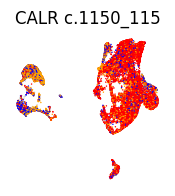

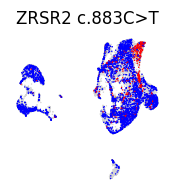

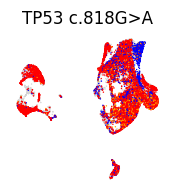

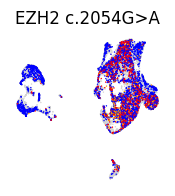

In [3]:
for variant in adata.obsm['genotype_call'].columns[0:5]:
    adata.obs[variant + '_call'] = adata.obsm['genotype_call'][variant] 
    print(variant, adata.obs[variant + '_call'].notna().sum()) ## check number of cells genotyped

    if variant == 'NRAS c.35G>A': ## skip NRAS because we plot it later
        continue
    
    fig,ax = plt.subplots(figsize=(2,2))
    sc.pl.umap(adata, color = variant + '_call', palette=color_palette, frameon=False, ax=ax, show=False, legend_loc=None,title = variant[0:15])
    
    plt.savefig('../plots/' + variant + '_UMAP.pdf')
